In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

DATA_PATH = "work_from_home_burnout_dataset.csv"
df = pd.read_csv(DATA_PATH)

# Target score (regresi)
TARGET_SCORE = "burnout_score"
TARGET_RISK  = "burnout_risk"

# X untuk regresi: drop label risk
X = df.drop(columns=[TARGET_SCORE, TARGET_RISK], errors="ignore")
y_score = df[TARGET_SCORE]
y_risk  = df[TARGET_RISK]  # hanya untuk belajar threshold

# auto detect kolom
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical:", cat_cols)
print("Numeric:", num_cols)
print("\nDistribusi risk:\n", y_risk.value_counts())

X_train, X_test, y_score_train, y_score_test, y_risk_train, y_risk_test = train_test_split(
    X, y_score, y_risk, test_size=0.2, random_state=42
)

Categorical: ['day_type']
Numeric: ['user_id', 'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours', 'task_completion_rate']

Distribusi risk:
 burnout_risk
Low       1527
Medium     253
High        20
Name: count, dtype: int64


In [2]:
from sklearn.ensemble import HistGradientBoostingRegressor

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.08,
        max_iter=400,
        random_state=42
    ))
])

reg.fit(X_train, y_score_train)
print("✅ Done training regressor.")

✅ Done training regressor.


MAE  : 4.9688
RMSE : 6.2514
R^2  : 0.9307


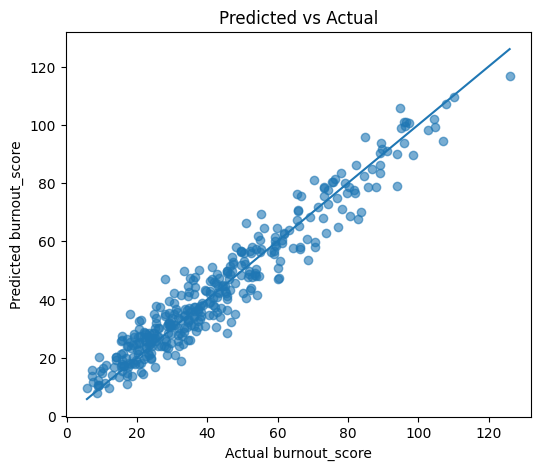

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

pred_score = reg.predict(X_test)

mae = mean_absolute_error(y_score_test, pred_score)
rmse = np.sqrt(mean_squared_error(y_score_test, pred_score))
r2 = r2_score(y_score_test, pred_score)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R^2  : {r2:.4f}")

plt.figure(figsize=(6,5))
plt.scatter(y_score_test, pred_score, alpha=0.6)
mn = min(y_score_test.min(), pred_score.min())
mx = max(y_score_test.max(), pred_score.max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Actual burnout_score")
plt.ylabel("Predicted burnout_score")
plt.title("Predicted vs Actual")
plt.show()

In [4]:
def compute_thresholds(score_series, risk_series):
    tmp = pd.DataFrame({"score": score_series, "risk": risk_series})

    # Pastikan labelnya konsisten
    # Kalau label beda (mis: "LOW"), nanti kita normalisasi:
    tmp["risk"] = tmp["risk"].astype(str).str.strip().str.title()

    q = tmp.groupby("risk")["score"].quantile([0.25, 0.75]).unstack()

    # kalau ada label tidak lengkap, fallback pakai quantile global
    if not set(["Low","Medium","High"]).issubset(set(q.index)):
        print("⚠️ Label risk tidak lengkap. Pakai threshold quantile global.")
        t1 = tmp["score"].quantile(0.33)
        t2 = tmp["score"].quantile(0.66)
        return float(t1), float(t2), q

    low_q75 = q.loc["Low", 0.75]
    med_q25 = q.loc["Medium", 0.25]
    med_q75 = q.loc["Medium", 0.75]
    high_q25 = q.loc["High", 0.25]

    t_low_med = float((low_q75 + med_q25) / 2)
    t_med_high = float((med_q75 + high_q25) / 2)

    # pastikan urutan benar
    if t_low_med >= t_med_high:
        # fallback jika overlap
        t_low_med = float(tmp["score"].quantile(0.33))
        t_med_high = float(tmp["score"].quantile(0.66))

    return t_low_med, t_med_high, q

t1, t2, qtable = compute_thresholds(y_score_train, y_risk_train)
print("✅ Thresholds:")
print("Low/Medium boundary:", t1)
print("Medium/High boundary:", t2)
print("\nQuantile per kelas:")
display(qtable)

✅ Thresholds:
Low/Medium boundary: 62.588750000000005
Medium/High boundary: 104.065

Quantile per kelas:


,0.25,0.75
risk,,
High,117.4550,125.790
Low,23.8850,49.035
Medium,76.1425,90.675


In [5]:
def score_to_risk(score, t1, t2):
    score = float(score)
    if score < t1:
        return "Low"
    elif score < t2:
        return "Medium"
    return "High"

pred_risk_from_score = [score_to_risk(s, t1, t2) for s in pred_score]
pred_risk_from_score = pd.Series(pred_risk_from_score)

print("Distribusi risk hasil mapping:")
print(pred_risk_from_score.value_counts())

Distribusi risk hasil mapping:
Low       294
Medium     62
High        4
Name: count, dtype: int64


              precision    recall  f1-score   support

        High     0.5000    1.0000    0.6667         2
         Low     0.9932    0.9574    0.9750       305
      Medium     0.7903    0.9245    0.8522        53

    accuracy                         0.9528       360
   macro avg     0.7612    0.9606    0.8313       360
weighted avg     0.9606    0.9528    0.9552       360



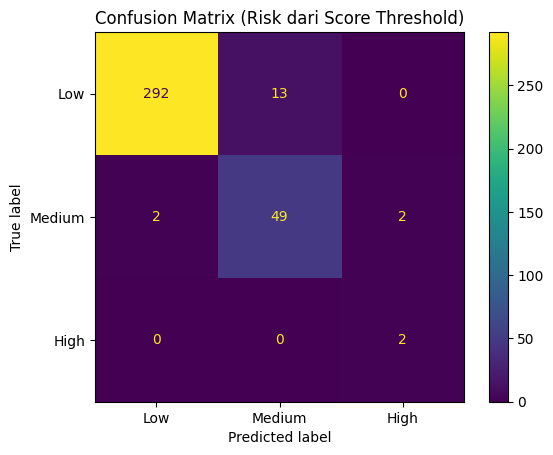

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_risk_test_norm = y_risk_test.astype(str).str.strip().str.title()

print(classification_report(y_risk_test_norm, pred_risk_from_score, digits=4))

cm = confusion_matrix(y_risk_test_norm, pred_risk_from_score, labels=["Low","Medium","High"])
disp = ConfusionMatrixDisplay(cm, display_labels=["Low","Medium","High"])
disp.plot(values_format="d")
plt.title("Confusion Matrix (Risk dari Score Threshold)")
plt.show()

In [7]:
import joblib, json

joblib.dump(reg, "burnout_score_regressor.joblib")

with open("risk_thresholds.json", "w") as f:
    json.dump({"t_low_med": t1, "t_med_high": t2}, f, indent=2)

print("✅ Saved:")
print("- burnout_score_regressor.joblib")
print("- risk_thresholds.json")

✅ Saved:
- burnout_score_regressor.joblib
- risk_thresholds.json


In [9]:
!pip -q install gradio joblib pandas

import gradio as gr
import pandas as pd
import joblib, json
import datetime as dt

# =========================
# LOAD MODEL + THRESHOLDS
# =========================
reg = joblib.load("burnout_score_regressor.joblib")

with open("risk_thresholds.json", "r") as f:
    th = json.load(f)

t1 = float(th["t_low_med"])   # boundary Low/Medium
t2 = float(th["t_med_high"])  # boundary Medium/High


# =========================
# HELPERS
# =========================
def clamp(x, lo=0, hi=100):
    return max(lo, min(hi, float(x)))

def score_to_risk(score, t1, t2):
    s = float(score)
    if s < t1:
        return "Low"
    elif s < t2:
        return "Medium"
    return "High"

def risk_badge(risk: str) -> str:
    r = str(risk).lower()
    if "low" in r:
        cls = "badge low"
    elif "medium" in r:
        cls = "badge med"
    else:
        cls = "badge high"
    return f'<span class="{cls}"><span class="dot"></span>{risk}</span>'

def score_level(score: float):
    s = float(score)
    if s < 35:
        return "Low", "low"
    elif s < 65:
        return "Medium", "med"
    return "High", "high"

def score_gauge(score: float) -> str:
    s = clamp(score, 0, 100)
    level, cls = score_level(s)
    return f"""
      <div class="row">
        <div>
          <div class="card-title">Burnout Score</div>
          <div class="big">{s:.2f}</div>
        </div>
        <div style="text-align:right;">
          {risk_badge(level)}
          <div class="hint" style="margin-top:8px;">0–100 (lebih tinggi → lebih rentan)</div>
        </div>
      </div>
      <div class="gauge">
        <div class="bar {cls}" style="width:{s}%;"></div>
      </div>
      <div class="scale"><span>0</span><span>25</span><span>50</span><span>75</span><span>100</span></div>
    """

def threshold_pills(t1, t2):
    # clamp agar UI tidak menampilkan >100 (biar jelas)
    t1c = clamp(t1, 0, 100)
    t2c = clamp(t2, 0, 100)
    return f"""
      <div class="pills">
        <span class="pill">Low &lt; {t1c:.2f}</span>
        <span class="pill">Medium: {t1c:.2f} – {t2c:.2f}</span>
        <span class="pill">High ≥ {t2c:.2f}</span>
      </div>
    """

def confidence_heuristic(score, t1, t2):
    # jarak score ke boundary terdekat → makin jauh makin yakin (heuristic)
    s = float(score)
    b1, b2 = float(t1), float(t2)
    nearest = min(abs(s - b1), abs(s - b2))
    conf = clamp(nearest / 25.0, 0, 1)  # 0..1
    return int(conf * 100)

def build_recommendations(work_hours, screen_time_hours, meetings_count,
                          breaks_taken, after_hours_work, sleep_hours, task_completion_rate, est_score):
    recs = []

    if sleep_hours < 6:
        recs.append("🛌 <b>Tidur < 6 jam</b> → targetkan 7–8 jam atau tambah power nap 20 menit.")
    if after_hours_work == 1:
        recs.append("🌙 <b>Kerja di luar jam kerja</b> → buat batas ‘shutdown’ (mis. 19:00) & matikan notifikasi kerja.")
    if work_hours >= 9:
        recs.append("⏱️ <b>Jam kerja tinggi (≥ 9 jam)</b> → time-boxing & blok fokus; evaluasi prioritas harian.")
    if screen_time_hours >= 10:
        recs.append("🖥️ <b>Screen time tinggi (≥ 10 jam)</b> → aturan 20-20-20 untuk mata.")
    if breaks_taken <= 1:
        recs.append("☕ <b>Break minim</b> → micro-break 5 menit tiap 60–90 menit.")
    if meetings_count >= 6:
        recs.append("📅 <b>Meeting banyak (≥ 6)</b> → konsolidasikan meeting, pakai agenda & batasi durasi.")
    if task_completion_rate < 60:
        recs.append("✅ <b>Completion rate rendah (&lt; 60%)</b> → pecah tugas besar jadi subtugas, pilih 1–3 prioritas utama.")

    if est_score >= 70:
        recs.append("🚨 <b>Score tinggi</b> → pertimbangkan diskusi dengan atasan/HR untuk redistribusi beban & recovery.")
    elif est_score >= 40:
        recs.append("⚠️ <b>Score sedang</b> → jaga ritme tidur, jeda teratur, kurangi kerja malam.")
    else:
        recs.append("✅ <b>Score rendah</b> → pertahankan kebiasaan baik, monitor jika jam kerja/screen time naik.")

    lis = "".join([f"<li>{r}</li>" for r in recs])

    return f"""
    <div class="card rec-card" style="margin-top:14px;">
      <div class="card-title">Recommendations</div>
      <ul class="recs">{lis}</ul>
    </div>
    """


# =========================
# PREDICT + EXPORT
# =========================
def predict_and_export(user_id, day_type, work_hours, screen_time_hours, meetings_count,
                       breaks_taken, after_hours_work, sleep_hours, task_completion_rate):

    # input row
    row = pd.DataFrame([{
        "user_id": int(user_id),
        "day_type": day_type,
        "work_hours": float(work_hours),
        "screen_time_hours": float(screen_time_hours),
        "meetings_count": int(meetings_count),
        "breaks_taken": int(breaks_taken),
        "after_hours_work": int(after_hours_work),
        "sleep_hours": float(sleep_hours),
        "task_completion_rate": float(task_completion_rate),
    }])

    # predict score
    est_score = float(reg.predict(row)[0])
    est_score = clamp(est_score, 0, 100)

    # risk dari threshold
    risk = score_to_risk(est_score, t1, t2)
    conf_pct = confidence_heuristic(est_score, t1, t2)

    # dashboard HTML
    html = f"""
    <div class="kpi-grid">
      <div class="card">
        <div class="card-title">Predicted Burnout Risk</div>
        <div class="row">
          <div class="big">{risk}</div>
          <div>{risk_badge(risk)}</div>
        </div>

        <div class="hint">
          Risk ditentukan dari burnout_score menggunakan threshold data-driven.
          Confidence (heuristic): <b>{conf_pct}%</b>
        </div>

        {threshold_pills(t1, t2)}
      </div>

      <div class="card">
        {score_gauge(est_score)}
      </div>
    </div>
    """

    # recommendations
    rec_html = build_recommendations(
        float(work_hours), float(screen_time_hours), int(meetings_count),
        int(breaks_taken), int(after_hours_work), float(sleep_hours), float(task_completion_rate),
        est_score
    )

    # export CSV
    ts = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
    out_path = f"prediction_{ts}.csv"

    export_row = {
        "timestamp": ts,
        "user_id": int(user_id),
        "day_type": day_type,
        "work_hours": float(work_hours),
        "screen_time_hours": float(screen_time_hours),
        "meetings_count": int(meetings_count),
        "breaks_taken": int(breaks_taken),
        "after_hours_work": int(after_hours_work),
        "sleep_hours": float(sleep_hours),
        "task_completion_rate": float(task_completion_rate),
        "predicted_burnout_score": float(est_score),
        "predicted_burnout_risk": risk,
        "t_low_med": float(t1),
        "t_med_high": float(t2),
        "confidence_heuristic_pct": conf_pct
    }

    pd.DataFrame([export_row]).to_csv(out_path, index=False)

    return html, rec_html, out_path


# =========================
# UI + CSS
# =========================
CSS = """
:root{
  --bg1:#070c16;
  --bg2:#0b1220;
  --border: rgba(255,255,255,.10);
  --text:#e8eef8;
  --muted:#a7b0bf;
  --shadow: 0 18px 45px rgba(0,0,0,.35);
  --radius: 18px;
}

.gradio-container{
  background: radial-gradient(1200px 600px at 20% 10%, #18264a 0%, var(--bg2) 45%, var(--bg1) 100%);
}

h1,h2,h3,p,label,span,.prose{ color: var(--text) !important; }

.header{
  padding: 18px 18px 0 18px;
}
.sub{
  color: var(--muted);
  margin-top: -6px;
}

.kpi-grid{
  display:grid;
  grid-template-columns: 1fr 1fr;
  gap: 14px;
  margin-top: 6px;
}

.card{
  background: linear-gradient(180deg, rgba(255,255,255,.10), rgba(255,255,255,.04));
  border: 1px solid var(--border);
  border-radius: var(--radius);
  padding: 16px 16px;
  box-shadow: var(--shadow);
}

.card-title{
  font-size: 12px;
  color: var(--muted);
  text-transform: uppercase;
  letter-spacing: .35px;
  margin-bottom: 8px;
}

.big{
  font-size: 34px;
  font-weight: 900;
  line-height: 1.1;
}

.row{
  display:flex;
  align-items:center;
  justify-content:space-between;
  gap: 12px;
}

.hint{
  color: var(--muted);
  font-size: 12px;
  margin-top: 10px;
  line-height: 1.35;
}

.badge{
  display:inline-flex;
  align-items:center;
  gap:8px;
  padding: 8px 12px;
  border-radius: 999px;
  border: 1px solid rgba(255,255,255,.14);
  font-size: 14px;
  font-weight: 900;
}
.dot{
  width:10px; height:10px; border-radius:999px;
  background: rgba(255,255,255,.7);
}
.badge.low{ background: rgba(34,197,94,.18); color:#86efac; }
.badge.low .dot{ background:#22c55e; }
.badge.med{ background: rgba(234,179,8,.18); color:#fde047; }
.badge.med .dot{ background:#eab308; }
.badge.high{ background: rgba(239,68,68,.18); color:#fecaca; }
.badge.high .dot{ background:#ef4444; }

.gauge{
  width:100%;
  height: 12px;
  border-radius: 999px;
  background: rgba(255,255,255,.10);
  overflow:hidden;
  border: 1px solid rgba(255,255,255,.12);
  margin-top: 10px;
}
.bar{ height:100%; border-radius:999px; }
.bar.low{ background: linear-gradient(90deg, rgba(34,197,94,.95), rgba(34,197,94,.35)); }
.bar.med{ background: linear-gradient(90deg, rgba(234,179,8,.95), rgba(234,179,8,.35)); }
.bar.high{ background: linear-gradient(90deg, rgba(239,68,68,.95), rgba(239,68,68,.35)); }

.scale{
  display:flex; justify-content:space-between;
  margin-top: 6px;
  color: var(--muted);
  font-size: 11px;
}

.pills{
  display:flex;
  flex-wrap:wrap;
  gap: 8px;
  margin-top: 10px;
}
.pill{
  padding: 6px 10px;
  border-radius: 999px;
  border: 1px solid rgba(255,255,255,.14);
  background: rgba(255,255,255,.04);
  color: var(--muted);
  font-size: 12px;
}

.rec-card ul{ margin: 10px 0 0 0; padding-left: 18px; }
.rec-card li{ margin: 6px 0; }
"""

with gr.Blocks(css=CSS, title="WFH Burnout Predictor") as demo:
    gr.HTML("""
      <div class="header">
        <h1>WFH Burnout Predictor</h1>
        <p class="sub">Prediksi <b>Burnout Score</b> (0–100) + <b>Burnout Risk</b> (Low/Medium/High) dengan rekomendasi & export CSV.</p>
      </div>
    """)

    with gr.Row():
        with gr.Column(scale=1):
            user_id = gr.Number(label="User ID", value=1, precision=0)
            day_type = gr.Dropdown(["Weekday", "Weekend"], label="Day Type", value="Weekday")
            work_hours = gr.Slider(0, 16, value=8, step=0.5, label="Work Hours")
            screen_time_hours = gr.Slider(0, 18, value=10, step=0.5, label="Screen Time Hours")
            meetings_count = gr.Slider(0, 20, value=3, step=1, label="Meetings Count")
            breaks_taken = gr.Slider(0, 10, value=2, step=1, label="Breaks Taken")
            after_hours_work = gr.Radio([0, 1], value=0, label="After Hours Work (0/1)")
            sleep_hours = gr.Slider(0, 12, value=7, step=0.5, label="Sleep Hours")
            task_completion_rate = gr.Slider(0, 100, value=80, step=1, label="Task Completion Rate (%)")

            with gr.Row():
                btn = gr.Button("Predict", variant="primary")
                clr = gr.Button("Clear Output", variant="secondary")

            gr.Markdown("**Examples:**")
            gr.Examples(
                examples=[
                    [1, "Weekday", 9, 11, 4, 1, 1, 5.5, 60],
                    [2, "Weekday", 7.5, 9, 2, 3, 0, 7.5, 85],
                    [3, "Weekend", 4, 6, 0, 4, 0, 8, 90],
                ],
                inputs=[user_id, day_type, work_hours, screen_time_hours, meetings_count,
                        breaks_taken, after_hours_work, sleep_hours, task_completion_rate],
                label="Try Examples"
            )

        with gr.Column(scale=1):
            out_html = gr.HTML()
            out_rec = gr.HTML()
            out_file = gr.File(label="Download Prediction CSV")

    btn.click(
        predict_and_export,
        inputs=[user_id, day_type, work_hours, screen_time_hours, meetings_count,
                breaks_taken, after_hours_work, sleep_hours, task_completion_rate],
        outputs=[out_html, out_rec, out_file]
    )

    clr.click(lambda: ("", "", None), None, [out_html, out_rec, out_file])

demo.launch(share=True)

/tmp/ipython-input-287/1859631827.py:345: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=CSS, title="WFH Burnout Predictor") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://721a81ed6e15fc7c50.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
